In [1]:
import os
import pickle
from collections import defaultdict

import numpy as np
import pandas as pd
import arviz as az

# --------------------------------------------------
# Config
# --------------------------------------------------
NETID = "k16v981"

VALID_BASINS = [
    "gulf_oman",
    "arabian_gulf",
    "red_sea",
    "gulf_aden",
]

VALID_TARGET_VARS = [
    "wbt_daily_peak",
    "tau_at_wbt_daily_peak",
    "t2m_at_wbt_daily_peak",
    "q_at_wbt_daily_peak",
]

CITY_TO_BASIN = {
    "muscat": "gulf_oman",
    "doha":   "arabian_gulf",
    "dubai":  "arabian_gulf",
    "jeddah": "red_sea",
    "aden":   "gulf_aden",
}

OUT_DIR = f"/home/{NETID}/my_work/code/arabian_peninsula/bayesian_extremes/data/wbt_sst_city_runs"
Q_LEVELS = [0.95, 0.99]

# --------------------------------------------------
# Helpers
# --------------------------------------------------
def idata_path(target_var, basin):
    return os.path.join(
        OUT_DIR,
        f"idata_city_hier_{target_var}_vs_sst_{basin}_JJAS.nc"
    )

def meta_path(target_var, basin):
    return os.path.join(
        OUT_DIR,
        f"meta_city_hier_{target_var}_vs_sst_{basin}_JJAS.pkl"
    )

def baseline_csv_path(target_var):
    return os.path.join(
        OUT_DIR,
        f"{target_var}_baseline_extremes_city_JJAS.csv"
    )

def stack_samples(da):
    return da.stack(sample=("chain", "draw")).values

def gpd_unconditional_quantile(u, sigma, xi, q, zeta_u, xi_tol=1e-6):
    """
    Unconditional quantile for a POT/GPD model.

    Parameters
    ----------
    u : float
        Threshold.
    sigma : array-like
        GPD scale parameter samples.
    xi : array-like
        GPD shape parameter samples.
    q : float
        Target unconditional quantile in the original distribution.
    zeta_u : float
        Exceedance probability P(X > u).
    """
    u = np.asarray(u)
    sigma = np.asarray(sigma)
    xi = np.asarray(xi)

    out_shape = np.broadcast(xi, sigma).shape
    q_u = 1.0 - zeta_u  # threshold quantile in unconditional distribution

    # if target q is at or below the threshold quantile, return u
    if q <= q_u + 1e-12:
        return np.broadcast_to(u, out_shape).astype(float)

    # conditional exceedance survival probability
    # P(X > x_q | X > u) = (1-q) / zeta_u
    s = (1.0 - q) / zeta_u

    out = np.empty(out_shape, dtype=float)
    near0 = np.abs(xi) < xi_tol

    out[~near0] = u + (sigma[~near0] / xi[~near0]) * (s ** (-xi[~near0]) - 1.0)
    out[near0]  = u + sigma[near0] * np.log(1.0 / s)

    return out

def load_idata_any(target_var, basin):
    nc_path = idata_path(target_var, basin)
    pkl_path = nc_path.replace(".nc", ".pkl")

    if os.path.exists(nc_path):
        try:
            return az.from_netcdf(nc_path, engine="netcdf4"), nc_path
        except Exception as e:
            print(f"⚠️ failed to open NetCDF for basin='{basin}', var='{target_var}': {e}")

    if os.path.exists(pkl_path):
        try:
            with open(pkl_path, "rb") as f:
                idata = pickle.load(f)
            return idata, pkl_path
        except Exception as e:
            print(f"⚠️ failed to open pickle for basin='{basin}', var='{target_var}': {e}")

    raise FileNotFoundError(
        f"No readable idata found for target_var='{target_var}', basin='{basin}'"
    )

# --------------------------------------------------
# Baseline aggregation
# --------------------------------------------------
def aggregate_baseline_one_var(target_var):
    print("=" * 80)
    print(f"BASELINE AGGREGATION: {target_var}")
    print("=" * 80)

    basin_to_cities = defaultdict(list)
    for city, basin in CITY_TO_BASIN.items():
        basin_to_cities[basin].append(city)

    all_rows = []

    for basin, target_cities in basin_to_cities.items():
        mpath = meta_path(target_var, basin)

        if not os.path.exists(mpath):
            print(f"⚠️ missing meta for basin='{basin}', var='{target_var}'")
            continue

        try:
            idata, used_path = load_idata_any(target_var, basin)
            print(f"✅ loaded {basin} from {used_path}")
        except Exception as e:
            print(f"⚠️ could not load idata for basin='{basin}', var='{target_var}': {e}")
            continue

        meta = pd.read_pickle(mpath)

        cities = list(meta["cities"])
        u_by_city = meta["u_by_city"]
        n_days_by_city = meta["n_days_by_city"]
        n_exc_by_city = meta["n_exc_by_city"]

        post = idata.posterior
        xi = stack_samples(post["xi"])
        a_city = post["a_city"].stack(sample=("chain", "draw"))

        city_to_i = {c: i for i, c in enumerate(cities)}
        cities_keep = [c for c in cities if c in target_cities]

        for city in cities_keep:
            i = city_to_i[city]
            u = float(u_by_city[city])

            n_days = int(n_days_by_city[city])
            n_exc  = int(n_exc_by_city[city])
            zeta_u = n_exc / n_days

            a = a_city.isel(city=i).values
            sigma0 = np.exp(a)

            for q in Q_LEVELS:
                x0 = gpd_unconditional_quantile(u, sigma0, xi, q, zeta_u)
                mean = float(np.mean(x0))
                lo, hi = az.hdi(x0, hdi_prob=0.94)

                all_rows.append({
                    "target_var": target_var,
                    "city": city,
                    "basin": basin,
                    "quantile": q,
                    "baseline_mean": mean,
                    "baseline_hdi_low": float(lo),
                    "baseline_hdi_high": float(hi),
                    "n_days": n_days,
                    "n_exc": n_exc,
                    "zeta_u": zeta_u,
                    "u": u,
                    "months": "".join(str(m) for m in meta["months"]),
                })

    baseline_df = pd.DataFrame(all_rows)
    out_csv = baseline_csv_path(target_var)
    baseline_df.to_csv(out_csv, index=False)
    print(f"✅ wrote baseline CSV: {out_csv}")
    display(baseline_df.sort_values(["city", "quantile"]).head(10))
    return baseline_df

# --------------------------------------------------
# Run all variables
# --------------------------------------------------
baseline_results = {}

for var in VALID_TARGET_VARS:
    try:
        baseline_results[var] = aggregate_baseline_one_var(var)
    except Exception as e:
        print(f"❌ failed baseline aggregation for {var}: {e}")

BASELINE AGGREGATION: wbt_daily_peak


ERROR 1: PROJ: proj_create_from_database: Open of /home/k16v981/.conda/envs/my_env/share/proj failed


✅ loaded gulf_oman from /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/wbt_sst_city_runs/idata_city_hier_wbt_daily_peak_vs_sst_gulf_oman_JJAS.nc
⚠️ failed to open NetCDF for basin='arabian_gulf', var='wbt_daily_peak': [Errno -51] NetCDF: Unknown file format: '/home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/wbt_sst_city_runs/idata_city_hier_wbt_daily_peak_vs_sst_arabian_gulf_JJAS.nc'
✅ loaded arabian_gulf from /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/wbt_sst_city_runs/idata_city_hier_wbt_daily_peak_vs_sst_arabian_gulf_JJAS.pkl
✅ loaded red_sea from /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/wbt_sst_city_runs/idata_city_hier_wbt_daily_peak_vs_sst_red_sea_JJAS.nc
✅ loaded gulf_aden from /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/wbt_sst_city_runs/idata_city_hier_wbt_daily_peak_vs_sst_gulf_aden_JJAS.nc
✅ wrote baseline CSV: /home/k16v981/my_work/code/arabian_peninsula/bayes

,target_var,city,basin,quantile,baseline_mean,baseline_hdi_low,baseline_hdi_high,n_days,n_exc,zeta_u,u,months
8,wbt_daily_peak,aden,gulf_aden,0.95,29.363397,29.363368,29.363431,9150,458,0.050055,29.363053,6789
9,wbt_daily_peak,aden,gulf_aden,0.99,29.805303,29.770561,29.847273,9150,458,0.050055,29.363053,6789
2,wbt_daily_peak,doha,arabian_gulf,0.95,30.113883,30.113834,30.113931,9150,458,0.050055,30.113387,6789
3,wbt_daily_peak,doha,arabian_gulf,0.99,30.752728,30.691449,30.809326,9150,458,0.050055,30.113387,6789
4,wbt_daily_peak,dubai,arabian_gulf,0.95,29.967018,29.966976,29.967064,9150,458,0.050055,29.966492,6789
5,wbt_daily_peak,dubai,arabian_gulf,0.99,30.643549,30.589469,30.694353,9150,458,0.050055,29.966492,6789
6,wbt_daily_peak,jeddah,red_sea,0.95,28.477257,28.477212,28.477304,9150,458,0.050055,28.476768,6789
7,wbt_daily_peak,jeddah,red_sea,0.99,29.106404,29.053389,29.161742,9150,458,0.050055,28.476768,6789
0,wbt_daily_peak,muscat,gulf_oman,0.95,28.090556,28.090493,28.090627,9150,458,0.050055,28.089792,6789
1,wbt_daily_peak,muscat,gulf_oman,0.99,29.072959,29.003423,29.152576,9150,458,0.050055,28.089792,6789


BASELINE AGGREGATION: tau_at_wbt_daily_peak
✅ loaded gulf_oman from /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/wbt_sst_city_runs/idata_city_hier_tau_at_wbt_daily_peak_vs_sst_gulf_oman_JJAS.nc
✅ loaded arabian_gulf from /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/wbt_sst_city_runs/idata_city_hier_tau_at_wbt_daily_peak_vs_sst_arabian_gulf_JJAS.nc
✅ loaded red_sea from /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/wbt_sst_city_runs/idata_city_hier_tau_at_wbt_daily_peak_vs_sst_red_sea_JJAS.nc
✅ loaded gulf_aden from /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/wbt_sst_city_runs/idata_city_hier_tau_at_wbt_daily_peak_vs_sst_gulf_aden_JJAS.nc
✅ wrote baseline CSV: /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/wbt_sst_city_runs/tau_at_wbt_daily_peak_baseline_extremes_city_JJAS.csv


,target_var,city,basin,quantile,baseline_mean,baseline_hdi_low,baseline_hdi_high,n_days,n_exc,zeta_u,u,months
8,tau_at_wbt_daily_peak,aden,gulf_aden,0.95,6.152238,6.152206,6.152270,9150,458,0.050055,6.151983,6789
9,tau_at_wbt_daily_peak,aden,gulf_aden,0.99,6.654542,6.590320,6.710978,9150,458,0.050055,6.151983,6789
2,tau_at_wbt_daily_peak,doha,arabian_gulf,0.95,6.180887,6.180844,6.180929,9150,458,0.050055,6.180519,6789
3,tau_at_wbt_daily_peak,doha,arabian_gulf,0.99,6.904707,6.818360,6.982832,9150,458,0.050055,6.180519,6789
4,tau_at_wbt_daily_peak,dubai,arabian_gulf,0.95,6.110236,6.110192,6.110285,9150,458,0.050055,6.109835,6789
5,tau_at_wbt_daily_peak,dubai,arabian_gulf,0.99,6.899988,6.814166,6.994251,9150,458,0.050055,6.109835,6789
6,tau_at_wbt_daily_peak,jeddah,red_sea,0.95,5.262499,5.262459,5.262540,9150,458,0.050055,5.262155,6789
7,tau_at_wbt_daily_peak,jeddah,red_sea,0.99,5.940189,5.865852,6.021196,9150,458,0.050055,5.262155,6789
0,tau_at_wbt_daily_peak,muscat,gulf_oman,0.95,4.676432,4.676346,4.676511,9150,458,0.050055,4.675690,6789
1,tau_at_wbt_daily_peak,muscat,gulf_oman,0.99,6.082772,5.924997,6.234628,9150,458,0.050055,4.675690,6789


BASELINE AGGREGATION: t2m_at_wbt_daily_peak
✅ loaded gulf_oman from /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/wbt_sst_city_runs/idata_city_hier_t2m_at_wbt_daily_peak_vs_sst_gulf_oman_JJAS.nc
✅ loaded arabian_gulf from /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/wbt_sst_city_runs/idata_city_hier_t2m_at_wbt_daily_peak_vs_sst_arabian_gulf_JJAS.nc
✅ loaded red_sea from /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/wbt_sst_city_runs/idata_city_hier_t2m_at_wbt_daily_peak_vs_sst_red_sea_JJAS.nc
✅ loaded gulf_aden from /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/wbt_sst_city_runs/idata_city_hier_t2m_at_wbt_daily_peak_vs_sst_gulf_aden_JJAS.nc
✅ wrote baseline CSV: /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/wbt_sst_city_runs/t2m_at_wbt_daily_peak_baseline_extremes_city_JJAS.csv


,target_var,city,basin,quantile,baseline_mean,baseline_hdi_low,baseline_hdi_high,n_days,n_exc,zeta_u,u,months
8,t2m_at_wbt_daily_peak,aden,gulf_aden,0.95,31.793632,31.793575,31.793695,9150,458,0.050055,31.793007,6789
9,t2m_at_wbt_daily_peak,aden,gulf_aden,0.99,32.665295,32.594885,32.744069,9150,458,0.050055,31.793007,6789
2,t2m_at_wbt_daily_peak,doha,arabian_gulf,0.95,38.273445,38.273302,38.273576,9150,458,0.050055,38.271873,6789
3,t2m_at_wbt_daily_peak,doha,arabian_gulf,0.99,40.462138,40.286965,40.646907,9150,458,0.050055,38.271873,6789
4,t2m_at_wbt_daily_peak,dubai,arabian_gulf,0.95,37.466846,37.466708,37.466980,9150,458,0.050055,37.465294,6789
5,t2m_at_wbt_daily_peak,dubai,arabian_gulf,0.99,39.628272,39.453425,39.807989,9150,458,0.050055,37.465294,6789
6,t2m_at_wbt_daily_peak,jeddah,red_sea,0.95,35.316191,35.316118,35.316260,9150,458,0.050055,35.315406,6789
7,t2m_at_wbt_daily_peak,jeddah,red_sea,0.99,36.407600,36.316831,36.497338,9150,458,0.050055,35.315406,6789
0,t2m_at_wbt_daily_peak,muscat,gulf_oman,0.95,38.282501,38.282388,38.282614,9150,458,0.050055,38.281222,6789
1,t2m_at_wbt_daily_peak,muscat,gulf_oman,0.99,40.063421,39.917282,40.210457,9150,458,0.050055,38.281222,6789


BASELINE AGGREGATION: q_at_wbt_daily_peak
✅ loaded gulf_oman from /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/wbt_sst_city_runs/idata_city_hier_q_at_wbt_daily_peak_vs_sst_gulf_oman_JJAS.nc
✅ loaded arabian_gulf from /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/wbt_sst_city_runs/idata_city_hier_q_at_wbt_daily_peak_vs_sst_arabian_gulf_JJAS.nc
✅ loaded red_sea from /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/wbt_sst_city_runs/idata_city_hier_q_at_wbt_daily_peak_vs_sst_red_sea_JJAS.nc
✅ loaded gulf_aden from /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/wbt_sst_city_runs/idata_city_hier_q_at_wbt_daily_peak_vs_sst_gulf_aden_JJAS.nc
✅ wrote baseline CSV: /home/k16v981/my_work/code/arabian_peninsula/bayesian_extremes/data/wbt_sst_city_runs/q_at_wbt_daily_peak_baseline_extremes_city_JJAS.csv


,target_var,city,basin,quantile,baseline_mean,baseline_hdi_low,baseline_hdi_high,n_days,n_exc,zeta_u,u,months
8,q_at_wbt_daily_peak,aden,gulf_aden,0.95,0.025170,0.025170,0.025170,9150,458,0.050055,0.025169,6789
9,q_at_wbt_daily_peak,aden,gulf_aden,0.99,0.026263,0.026139,0.026381,9150,458,0.050055,0.025169,6789
2,q_at_wbt_daily_peak,doha,arabian_gulf,0.95,0.025868,0.025868,0.025868,9150,458,0.050055,0.025867,6789
3,q_at_wbt_daily_peak,doha,arabian_gulf,0.99,0.027275,0.027129,0.027413,9150,458,0.050055,0.025867,6789
4,q_at_wbt_daily_peak,dubai,arabian_gulf,0.95,0.025621,0.025621,0.025621,9150,458,0.050055,0.025620,6789
5,q_at_wbt_daily_peak,dubai,arabian_gulf,0.99,0.027244,0.027085,0.027398,9150,458,0.050055,0.025620,6789
6,q_at_wbt_daily_peak,jeddah,red_sea,0.95,0.023294,0.023294,0.023295,9150,458,0.050055,0.023294,6789
7,q_at_wbt_daily_peak,jeddah,red_sea,0.99,0.024549,0.024413,0.024682,9150,458,0.050055,0.023294,6789
0,q_at_wbt_daily_peak,muscat,gulf_oman,0.95,0.022645,0.022645,0.022645,9150,458,0.050055,0.022643,6789
1,q_at_wbt_daily_peak,muscat,gulf_oman,0.99,0.024856,0.024666,0.025068,9150,458,0.050055,0.022643,6789


/tmp/ipykernel_166838/877160596.py:260: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.07, 1, 0.95])


Saved PNG: ../figures/wbt_city_basin_warming_byvar/wbt_daily_peak_city_basin_warming_2panel.png
Saved PDF: ../figures/wbt_city_basin_warming_byvar/wbt_daily_peak_city_basin_warming_2panel_manuscript.pdf


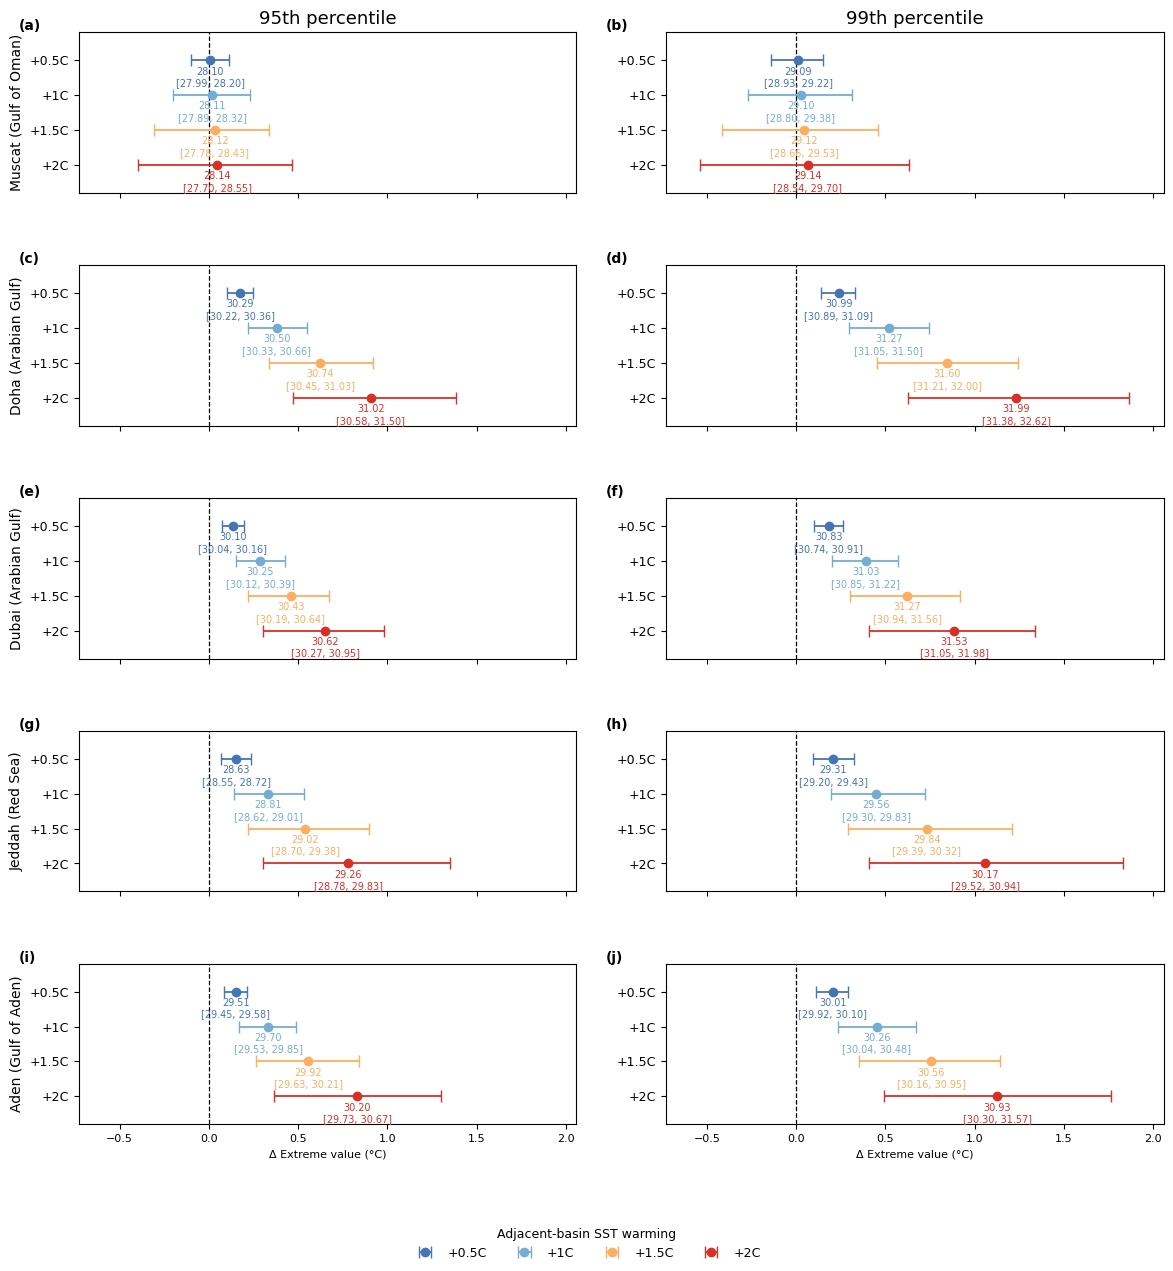

/tmp/ipykernel_166838/877160596.py:260: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.07, 1, 0.95])


Saved PNG: ../figures/wbt_city_basin_warming_byvar/tau_at_wbt_daily_peak_city_basin_warming_2panel.png
Saved PDF: ../figures/wbt_city_basin_warming_byvar/tau_at_wbt_daily_peak_city_basin_warming_2panel_manuscript.pdf


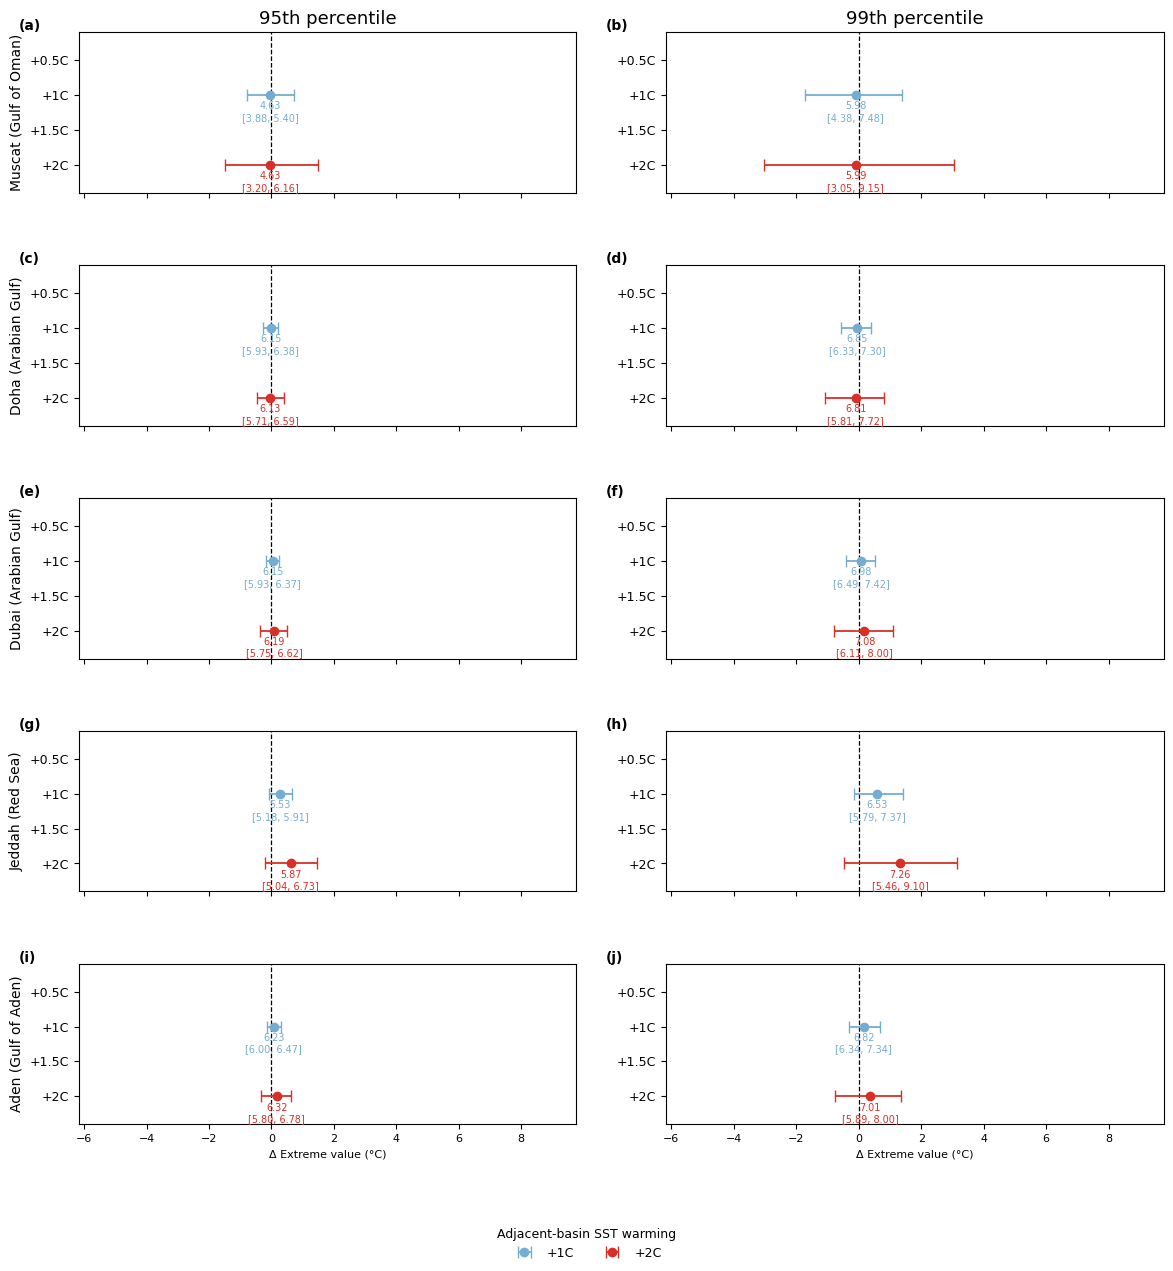

/tmp/ipykernel_166838/877160596.py:260: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.07, 1, 0.95])


Saved PNG: ../figures/wbt_city_basin_warming_byvar/t2m_at_wbt_daily_peak_city_basin_warming_2panel.png
Saved PDF: ../figures/wbt_city_basin_warming_byvar/t2m_at_wbt_daily_peak_city_basin_warming_2panel_manuscript.pdf


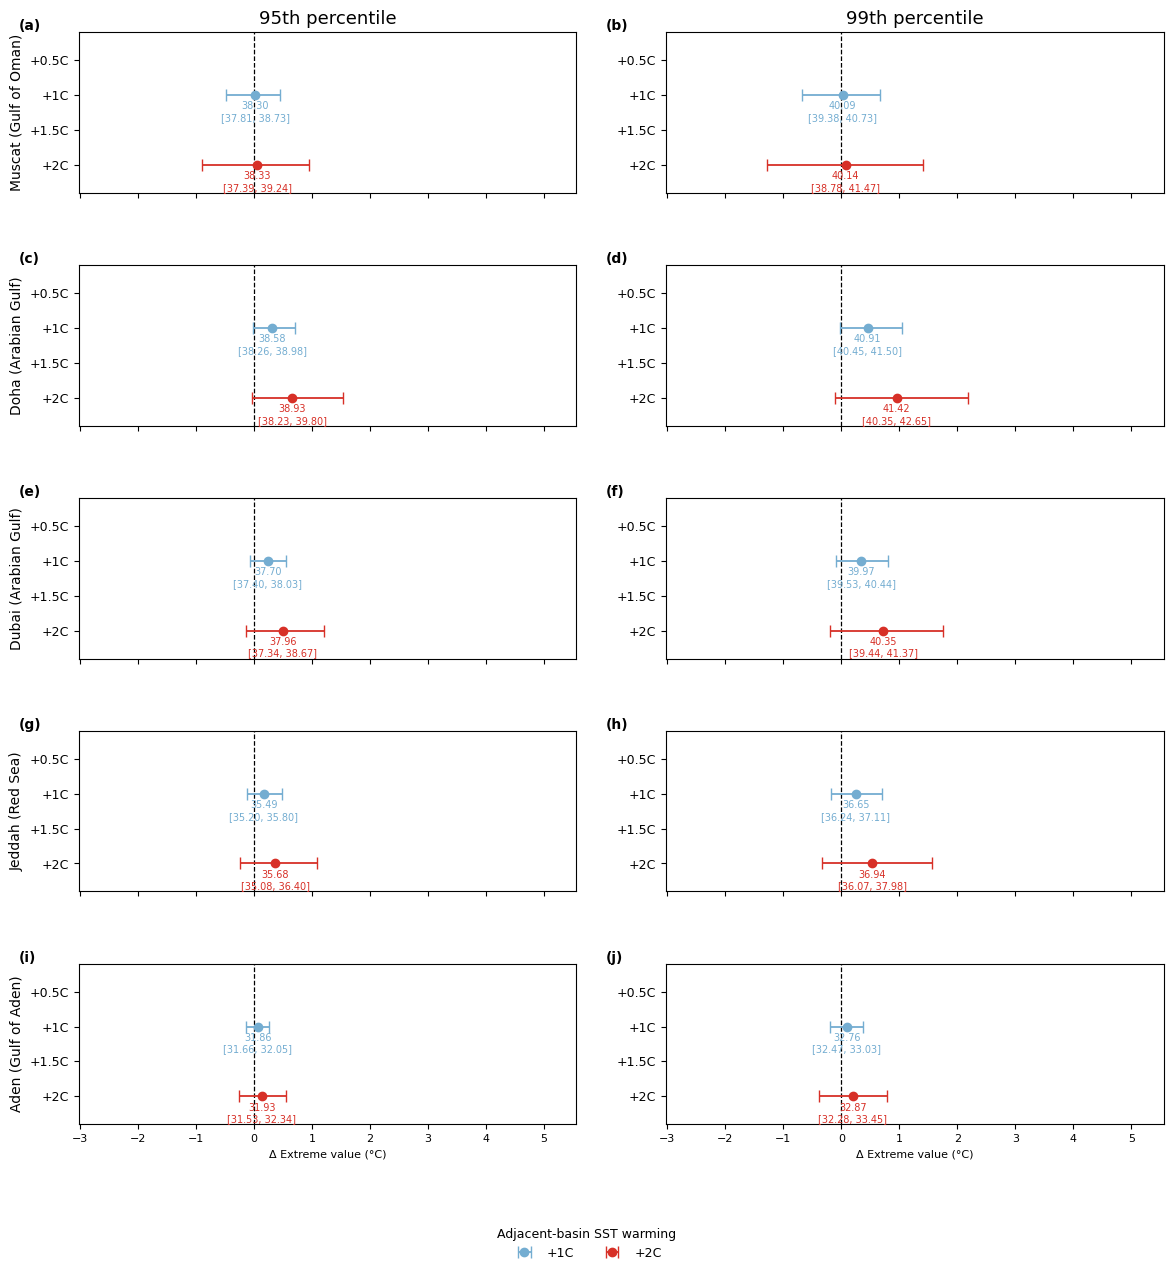

/tmp/ipykernel_166838/877160596.py:260: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.07, 1, 0.95])


Saved PNG: ../figures/wbt_city_basin_warming_byvar/q_at_wbt_daily_peak_city_basin_warming_2panel.png
Saved PDF: ../figures/wbt_city_basin_warming_byvar/q_at_wbt_daily_peak_city_basin_warming_2panel_manuscript.pdf


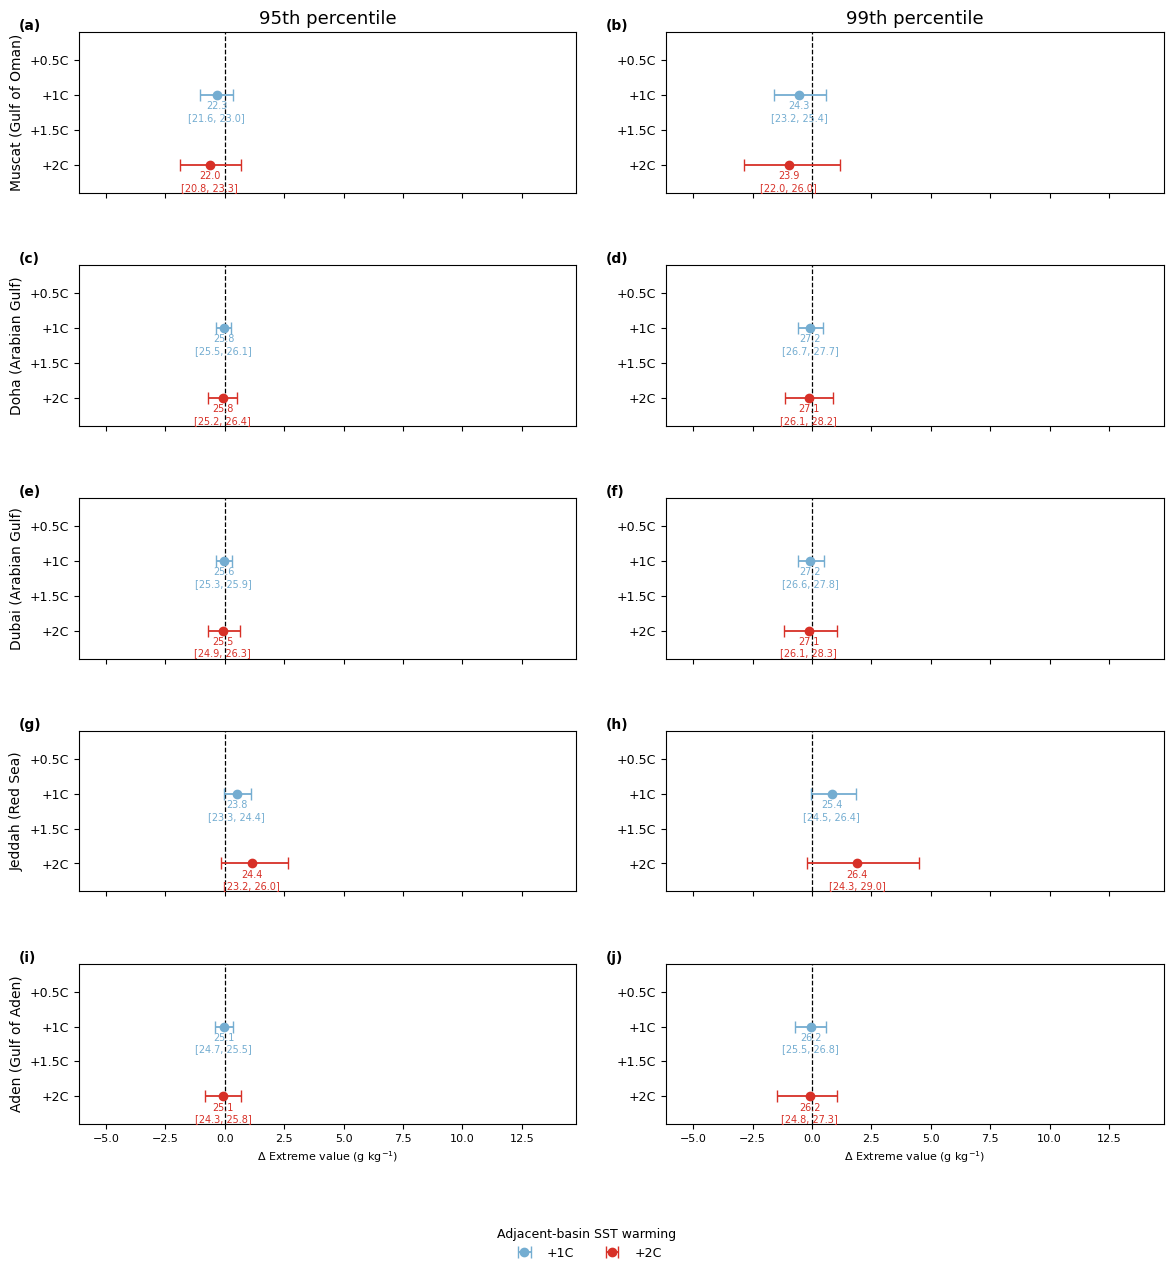

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# --------------------------------------------------
# ERL manuscript style
# --------------------------------------------------
ERL_RC = {
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "savefig.transparent": False,
    "path.simplify": False,
}
mpl.rcParams.update(ERL_RC)

# --------------------------------------------------
# Inputs
# --------------------------------------------------
DATA_DIR = "../data/wbt_sst_city_runs"
FIG_DIR = "../figures/wbt_city_basin_warming_byvar"
os.makedirs(FIG_DIR, exist_ok=True)

TARGET_VARS = [
    "wbt_daily_peak",
    "tau_at_wbt_daily_peak",
    "t2m_at_wbt_daily_peak",
    "q_at_wbt_daily_peak",
]

VAR_LABELS = {
    "wbt_daily_peak": "Daily Max WBT",
    "tau_at_wbt_daily_peak": "Tau at WBT Peak",
    "t2m_at_wbt_daily_peak": "T2M at WBT Peak",
    "q_at_wbt_daily_peak": "Specific Humidity at WBT Peak",
}

VAR_UNITS = {
    "wbt_daily_peak": "°C",
    "tau_at_wbt_daily_peak": "°C",
    "t2m_at_wbt_daily_peak": "°C",
    "q_at_wbt_daily_peak": "g kg$^{-1}$",
}

CITY_TO_BASIN = {
    "muscat": "gulf_oman",
    "doha":   "arabian_gulf",
    "dubai":  "arabian_gulf",
    "jeddah": "red_sea",
    "aden":   "gulf_aden",
}

cities = list(CITY_TO_BASIN.keys())
quantiles = [0.95, 0.99]
warm_order = ["+0.5C", "+1C", "+1.5C", "+2C"]

WARM_COLORS = {
    "+0.5C": "#4575b4",
    "+1C": "#74add1",
    "+1.5C": "#fdae61",
    "+2C": "#d73027",
}

warm_offsets = {
    "+0.5C": -0.80,
    "+1C":   -0.30,
    "+1.5C":  0.30,
    "+2C":    0.80,
}

SEA_LABELS = {
    "arabian_gulf": "Arabian Gulf",
    "red_sea": "Red Sea",
    "gulf_aden": "Gulf of Aden",
    "gulf_oman": "Gulf of Oman",
}

# --------------------------------------------------
# Load data
# --------------------------------------------------
impact_by_var = {}
baseline_by_var = {}

for var in TARGET_VARS:
    impact_path = os.path.join(
        DATA_DIR,
        f"{var}_city_response_to_adjacent_basin_warming_ALLBASINS_JJAS.csv"
    )
    baseline_path = os.path.join(
        DATA_DIR,
        f"{var}_baseline_extremes_city_JJAS.csv"
    )

    impact_df = pd.read_csv(impact_path)
    baseline_df = pd.read_csv(baseline_path)

    # keep only adjacent-basin rows
    impact_df = impact_df[
        impact_df.apply(lambda r: CITY_TO_BASIN.get(r["city"], None) == r["basin_warmed"], axis=1)
    ].copy()

    impact_df["quantile"] = impact_df["quantile"].astype(float)
    baseline_df["quantile"] = baseline_df["quantile"].astype(float)

    # convert q from kg/kg to g/kg for plotting
    if var == "q_at_wbt_daily_peak":
        for col in ["delta_mean", "delta_hdi_low", "delta_hdi_high"]:
            impact_df[col] = 1000.0 * impact_df[col]

        for col in ["baseline_mean", "baseline_hdi_low", "baseline_hdi_high", "u"]:
            if col in baseline_df.columns:
                baseline_df[col] = 1000.0 * baseline_df[col]

    impact_by_var[var] = impact_df
    baseline_by_var[var] = baseline_df

# --------------------------------------------------
# Make one figure per variable
# --------------------------------------------------
for var in TARGET_VARS:
    impact_df = impact_by_var[var]
    baseline_df = baseline_by_var[var]

    base_lookup = baseline_df.set_index(["city", "quantile"])

    # x-limits per variable
    x_lo = impact_df["delta_hdi_low"].min()
    x_hi = impact_df["delta_hdi_high"].max()
    pad = 0.08 * (x_hi - x_lo) if x_hi > x_lo else 0.2
    xlim = (x_lo - pad, x_hi + pad)

    fig, axes = plt.subplots(
        nrows=len(cities),
        ncols=len(quantiles),
        figsize=(14, 2.6 * len(cities)),
        sharex=True,
        squeeze=False,
        gridspec_kw={"hspace": 0.45, "wspace": 0.18}
    )
    
    for i, city in enumerate(cities):
        basin = CITY_TO_BASIN[city]
    
        for j, q in enumerate(quantiles):
            ax = axes[i, j]
            panel_idx = i * len(quantiles) + j
            label = f"({chr(97 + panel_idx)})"
            
            ax.text(
                -0.12, 1.08, label,
                transform=ax.transAxes,
                fontsize=10,
                fontweight="bold",
                va="top",
                ha="left"
            )
            ax.axvline(0, linestyle="--", linewidth=0.9, color="k")
            ax.set_xlim(xlim)
    
            sub = impact_df[
                (impact_df["city"] == city) &
                (impact_df["basin_warmed"] == basin) &
                (impact_df["quantile"] == float(q))
            ].copy()
    
            sub = sub.set_index("warming").reindex(warm_order)
    
            try:
                b = base_lookup.loc[(city, float(q))]
                base_mean = float(b["baseline_mean"])
            except KeyError:
                base_mean = np.nan
    
            # local y positions inside each city panel
            local_y = np.arange(len(warm_order))[::-1]
    
            for k, w in enumerate(warm_order):
                if w not in sub.index or pd.isna(sub.loc[w, "delta_mean"]):
                    continue
    
                yy = local_y[k]
    
                dmean = float(sub.loc[w, "delta_mean"])
                dlo   = float(sub.loc[w, "delta_hdi_low"])
                dhi   = float(sub.loc[w, "delta_hdi_high"])
    
                ax.errorbar(
                    dmean, yy,
                    xerr=[[dmean - dlo], [dhi - dmean]],
                    fmt="o",
                    color=WARM_COLORS[w],
                    capsize=4,
                    linewidth=1.3,
                    markersize=6,
                    label=w if (i == 0 and j == 0) else None,
                )
    
                if np.isfinite(base_mean):
                    abs_mean = base_mean + dmean
                    abs_lo   = base_mean + dlo
                    abs_hi   = base_mean + dhi
    
                    if var == "q_at_wbt_daily_peak":
                        txt = f"{abs_mean:.1f}\n[{abs_lo:.1f}, {abs_hi:.1f}]"
                    else:
                        txt = f"{abs_mean:.2f}\n[{abs_lo:.2f}, {abs_hi:.2f}]"
    
                    ax.text(
                        dmean, yy - 0.18,
                        txt,
                        ha="center",
                        va="top",
                        fontsize=7,
                        color=WARM_COLORS[w],
                    )
    
            ax.set_yticks(local_y)
            ax.set_yticklabels(warm_order, fontsize=9)
            ax.set_ylim(-0.8, len(warm_order) - 0.2)
    
            if j == 0:
                basin_label = SEA_LABELS.get(basin, basin.replace("_", " ").title())
                ax.set_ylabel(f"{city.title()} ({basin_label})", fontsize=10)
    
            if i == 0:
                ax.set_title(f"{int(q*100)}th percentile", fontsize=13)
    
            if i == len(cities) - 1:
                ax.set_xlabel(f"Δ Extreme value ({VAR_UNITS[var]})")

        

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        title="Adjacent-basin SST warming",
        loc="lower center",
        ncol=len(warm_order),
        frameon=False
    )

    # -------------------------------
    # Save PNG WITH title
    # -------------------------------
    st = fig.suptitle(
        f"{VAR_LABELS[var]} response to adjacent-basin SST warming (JJAS)\n"
        "Points/bars show delta mean ± 94% HDI relative to baseline.",
        y=0.98,
        fontsize=15
    )
    
    fig.tight_layout(rect=[0, 0.07, 1, 0.95])
    
    png_out = os.path.join(FIG_DIR, f"{var}_city_basin_warming_2panel.png")
    fig.savefig(png_out, dpi=250, bbox_inches="tight")
    print(f"Saved PNG: {png_out}")
    
    # -------------------------------
    # Save PDF WITHOUT title
    # -------------------------------
    st.remove()
    
    # DO NOT call tight_layout again
    fig.subplots_adjust(top=0.95)
    
    pdf_out = os.path.join(FIG_DIR, f"{var}_city_basin_warming_2panel_manuscript.pdf")
    fig.savefig(pdf_out)
    print(f"Saved PDF: {pdf_out}")
    
    plt.show()
    plt.close()